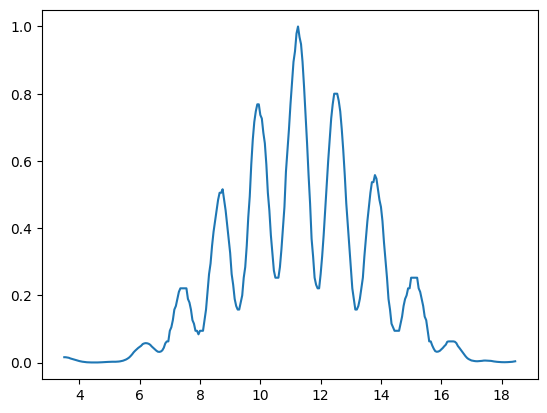

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv(r"C:\Users\rsrut\Downloads\double-slit data for central fringe-2.csv")
plt.plot(data['position'],data['normalized intensity'])


x = data['position'].values
int_avg = data['Average Intensity'].values
theta = data['theta'].values
int_norm = data['normalized intensity'].values
stdev = data['STDEV'].values
norm_stdev = data['normalizd stdev']

lambda_nm=655
lambda_mm= 655*10**(-6)


Goodness of fit, R_squared value is 0.910941106711772
Position of Principal maxima= 0.001303697650381089
Position of first minima= 0.0006518488251905445
Slit width in mm= 0.10248893223889562
Slit seperation in mm= 0.5024171055371116


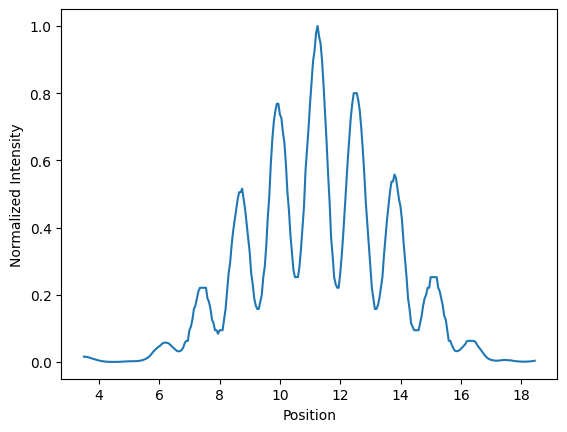

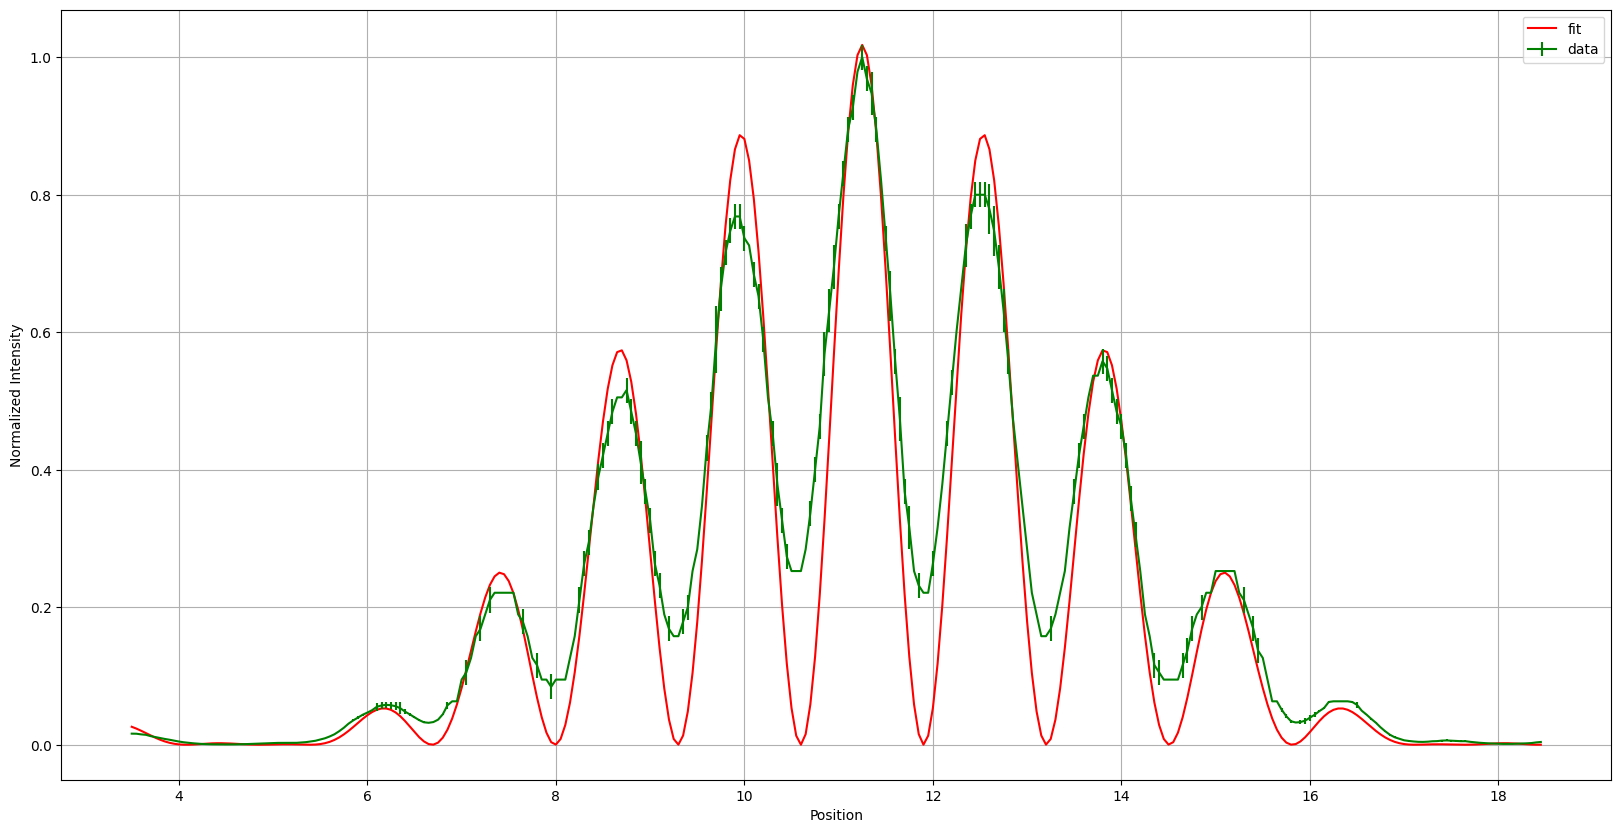

In [17]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv(r"C:\Users\rsrut\Downloads\double-slit data for central fringe-2.csv")
plt.plot(data['position'],data['normalized intensity'])
plt.xlabel('Position')
plt.ylabel('Normalized Intensity')

x = data['position'].values
int_avg = data['Average Intensity'].values
theta = data['theta'].values
int_norm = data['normalized intensity'].values
stdev = data['STDEV'].values
norm_stdev = data['normalizd stdev']

lambda_nm=655
lambda_mm= 655*10**(-6)

def fn(theta,a,d,I0):
    beta= np.pi*a*np.sin(theta)/lambda_mm
    gamma= np.pi*d*np.sin(theta)/lambda_mm
    I = (I0*np.cos(gamma)**2)*(np.sinc(beta/np.pi)**2)
    return I

from scipy.optimize import curve_fit

initial_guesses = [0.1,0.5,1]
params, params_cov  = curve_fit(fn,theta,int_norm,p0=initial_guesses)
a,d,I0= params



y1 = fn(theta,a,d,I0)
tss = np.sum((int_norm- np.mean(y1))**2)
rss = np.sum((int_norm-y1)**2)

r_squared = 1- (rss/tss)

print("Goodness of fit, R_squared value is", r_squared)

principal_maxima= lambda_mm/ d
first_minima = lambda_mm/(2*d)


residuals = fn(theta,a,d,I0)- int_norm

print("Position of Principal maxima=", principal_maxima)
print("Position of first minima=" , first_minima)
print("Slit width in mm=",a)
print("Slit seperation in mm=",d)

plt.figure(figsize=(20,10))
plt.plot(x,fn(theta,*params),label='fit',color='red')
plt.errorbar(x,int_norm,norm_stdev,label='data', color='green')
plt.xlabel('Position')
plt.ylabel('Normalized Intensity')
plt.legend()
plt.grid(True)
plt.show()

Text(0, 0.5, 'Normalized Intensity')

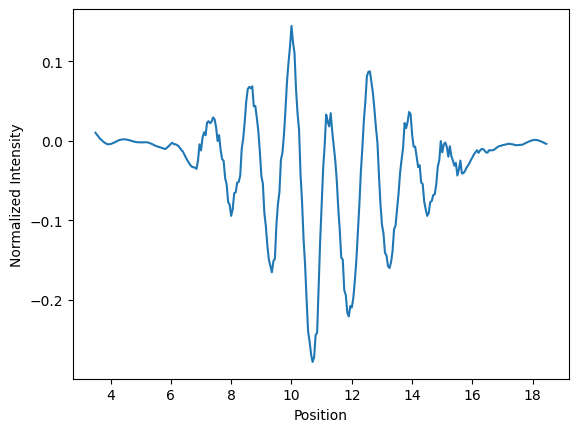

In [16]:
plt.plot(x,residuals)
plt.xlabel('Position')
plt.ylabel('Normalized Intensity')